In [1]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from scipy.signal import windows

import itertools

D = 1

N = 10000
L = 5.*np.pi

N_f = 4*N
L_f = 4*L

grid_dims = [N for _ in range(D)]
grid_dims_f = [N_f for _ in range(D)]

phys_dims = [L for _ in range(D)]
phys_dims_f = [L_f for _ in range(D)]

twopi = 2.*np.pi

dk_f = twopi/L_f
dk = twopi/L

dx_f = L_f/N_f
dx = L/N

BREAK = 100 * dk_f

In [2]:
f_f = fbm.create_fbm([N_f for _ in range(D)], phys_dims_f, (-1., -5./3.), gfunc='smooth_pow', func_kwargs={'breaks': (BREAK,), 'delta': 0.25})
#f_f = fbm.create_fbm([N_f for _ in range(D)], phys_dims_f, (-5./3.,), gfunc='pure_pow')
f = f_f[N_f//2-N//2:N_f//2+N//2]
f = f - np.mean(f)
f_p = windows.tukey(N, 0.1) * f

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:146: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)


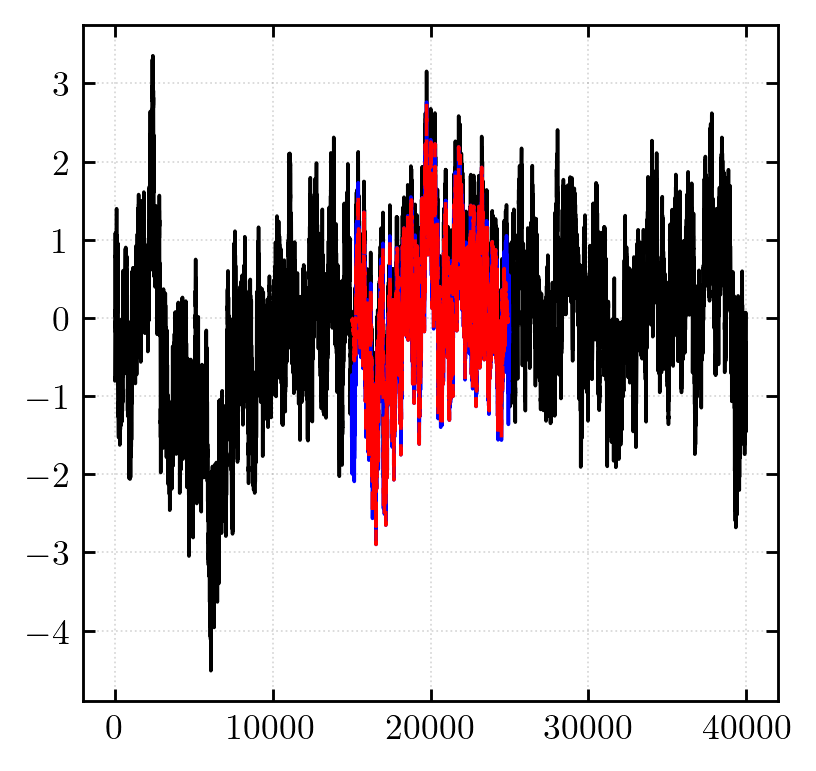

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
ax.plot(f_f, linewidth=1., color='black')
ax.plot(np.arange(N_f//2-N//2, N_f//2+N//2), f, linewidth=1., color='blue')
ax.plot(np.arange(N_f//2-N//2, N_f//2+N//2), f_p, linewidth=1., color='red', linestyle=(0,(5,5)))
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

Text(0.5, 0, 'Wavenumber, $k$')

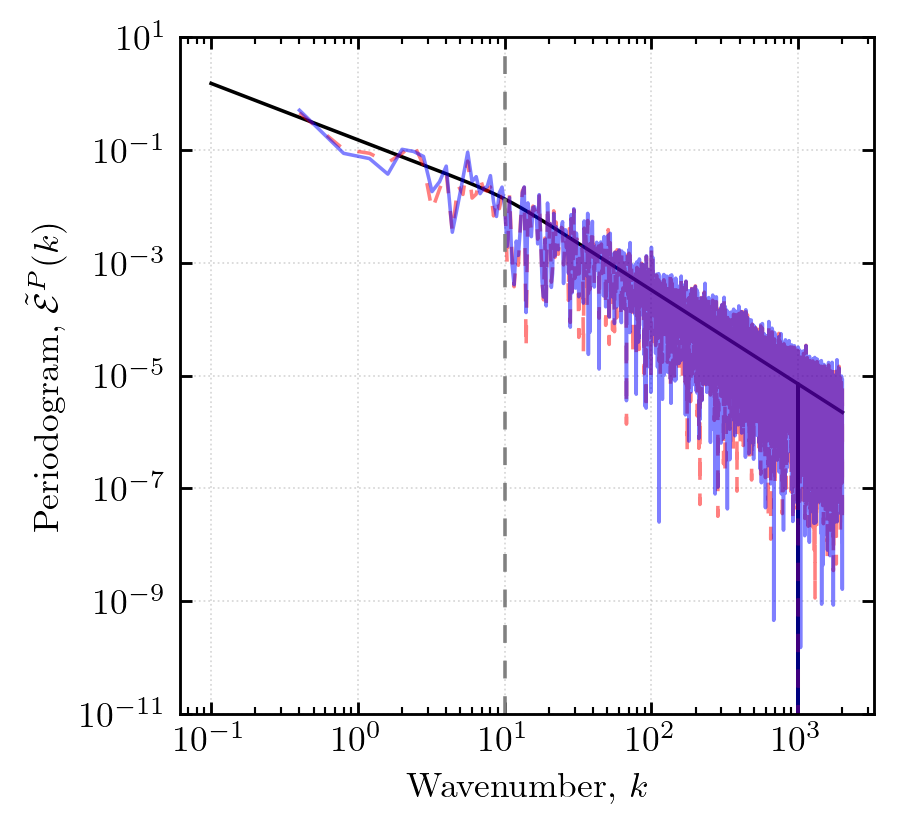

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

kD_f, fekD_f = per_spectra.modal_spectrum(f_f, phys_dims=phys_dims_f)
fekD_f = fekD_f * (dk_f/twopi)**D
k_f, fek_f, _ = spectra_base.spectrum_integrate(kD_f, fekD_f, spec_type='omni', lenn=phys_dims_f)
ax.loglog(k_f, fek_f, color='black', linewidth=1.)

kD_p, fekD_p = per_spectra.modal_spectrum(f_p, phys_dims=phys_dims)
fekD_p = fekD_p * (dk/twopi)**D
k_p, fek_p, _ = spectra_base.spectrum_integrate(kD_p, fekD_p, spec_type='omni', lenn=phys_dims)
ax.loglog(k_p, fek_p, color='red', linewidth=1., linestyle=(0,(5,5)), alpha=0.5)

kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
fekD = fekD * (dk/twopi)**D
k, fek, _ = spectra_base.spectrum_integrate(kD, fekD, spec_type='omni', lenn=phys_dims)
ax.loglog(k, fek, color='blue', linewidth=1., alpha=0.5)

ax.axvline(BREAK, linewidth=1., color='gray', linestyle=(0,(5,5)))

ax.set_ylim((1e-11, 1e1))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'Periodogram, $\tilde{\mathcal{E}}^P(k)$')
ax.set_xlabel(r'Wavenumber, $k$')

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Text(0.5, 0, '$\\lambda$')

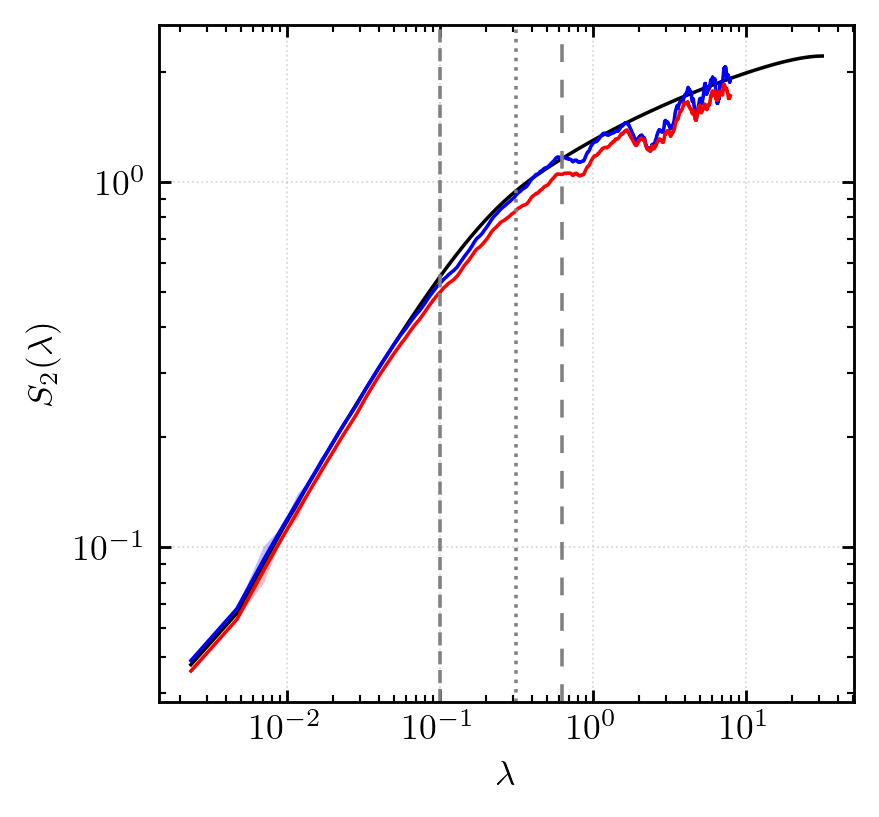

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)


lv_f = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims_f])
sf_f = strfn.process_lags(f_f, f_f, lv_f, lenn=phys_dims_f, shape=[2*n+1 for n in grid_dims_f], orders=[2], periodic=True)[0]
lvm_f = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims_f]) * dx_f

l_f, sf2_f, w_f = statistics_base.bin_data(lvm_f, sf_f, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx_f, max_bin=L_f/2., num_bins=N_f//3, bin_loc='true_center')

ax.loglog(l_f, sf2_f, linewidth=1., color='black')


lv = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf = strfn.process_lags(f, f, lv, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=False)[0]
lvm = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims])*dx

l, sf2, w = statistics_base.bin_data(lvm, sf, bin_func=np.nanmean, cut_excess=True, min_bin=dx, max_bin=L/2., num_bins=N//3, bin_loc='true_center')
_l, sf2err, _ = statistics_base.bin_data(lvm, sf, bin_func=np.nanstd, cut_excess=True, min_bin=dx, max_bin=L/2., num_bins=N//3, bin_loc='true_center')

ax.fill_between(_l, sf2-sf2err, sf2+sf2err, color='blue', alpha=0.25, edgecolor='none')
ax.loglog(l, sf2, linewidth=1., color='blue')


lv_p = statfunc_base.get_all_lagvecs([2*n+1 for n in grid_dims])
sf_p = strfn.process_lags(f_p, f_p, lv_p, lenn=phys_dims, shape=[2*n+1 for n in grid_dims], orders=[2], periodic=True)[0]
lvm_p = statfunc_base.get_lagvec_magnitude_array([2*n+1 for n in grid_dims]) * dx
l_p, sf2_p, w_p = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanmean, cut_excess=True, nan_small=False, min_bin=dx, max_bin=L/2., num_bins=N//3, bin_loc='true_center')
_l_p, sf2_perr, _ = statistics_base.bin_data(lvm_p, sf_p, bin_func=np.nanstd, cut_excess=True, nan_small=False, min_bin=dx, max_bin=L/2., num_bins=N//3, bin_loc='true_center')

ax.fill_between(_l_p, sf2_p-sf2_perr, sf2_p+sf2_perr, color='red', alpha=0.25, edgecolor='none')
ax.loglog(l_p, sf2_p, linewidth=1., color='red')


ax.axvline(2.*np.pi/BREAK, linewidth=1., color='gray', linestyle=(0,(5,5)))
ax.axvline(np.pi/BREAK, linewidth=1., color='gray', linestyle=':')
ax.axvline(1./BREAK, linewidth=1., color='gray', linestyle='--')

ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'$S_2(\lambda)$')
ax.set_xlabel(r'$\lambda$')


In [6]:
# def omni_spectrum_2(ell, sf2, phys_dims, grid_dims):
#     _dx = phys_dims[0] / grid_dims[0]
#     dS = np.gradient(sf2, _dx)
#     dell = np.gradient(ell, _dx)
#     fek = (ell)**2 * (dS) * (1. / 2.) * (twopi/dk)
#     kk = 1. / ell
#     return kk[::-1], fek[::-1]

# def omni_spectrum(ell, sf2, phys_dims, grid_dims):
#     kk = 1. / ell
#     fek = (1. / 2.) * sf2 * ell * (twopi/dk)
#     return kk[::-1], fek[::-1]

def omni_spectrum(ell, sf2, phys_dims, grid_dims, a=1., b=1.):

    _dx = phys_dims[0]/grid_dims[0]
    _dk = 2.*np.pi/phys_dims[0]

    dS = np.gradient(sf2, _dx)
    dell = np.gradient(ell, _dx)

    fek = (ell)**2 * (dS/dell) * (1. / 2.) / a
    kk = b / ell

    return kk[::-1], fek[::-1]

lk, sfek = omni_spectrum(l, sf2, phys_dims, grid_dims)
lk_f, sfek_f = omni_spectrum(l_f, sf2_f, phys_dims_f, grid_dims_f)
lk_p, sfek_p = omni_spectrum(l_p, sf2_p, phys_dims, grid_dims)

#sfek_f = sfek_f * (dk_f/twopi)**D
#sfek = sfek * (dk/twopi)**D
#sfek_p = sfek_p * (dk/twopi)**D

# lk, sfek = omni_spectrum(l, sf2, phys_dims, grid_dims)
# lk2, sfek2 = omni_spectrum_2(l, sf2, phys_dims, grid_dims)

# lk_f, sfek_f = omni_spectrum_2(l_f, sf2_f, phys_dims_f, grid_dims_f)
# lk_p, sfek_p = omni_spectrum_2(l_p, sf2_p, phys_dims, grid_dims)

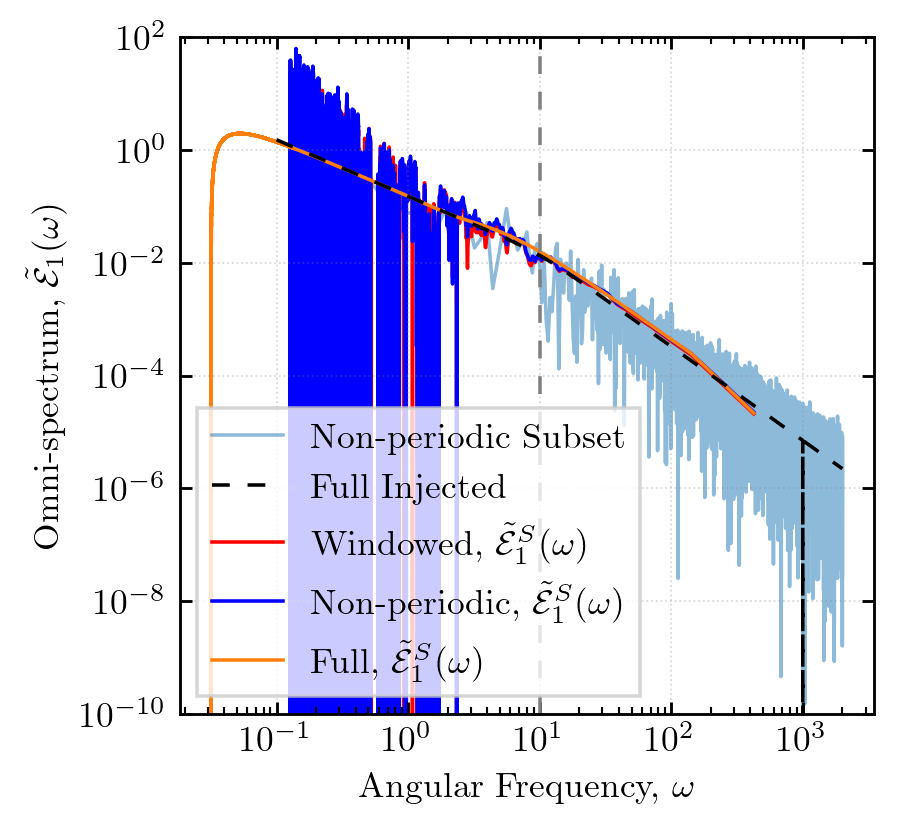

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.loglog(k, fek, linewidth=1., alpha=0.5, zorder=0, label='Non-periodic Subset')

ax.loglog(k_f, fek_f, linewidth=1., alpha=1., color='black', zorder=2, linestyle=(0,(5,5)), label='Full Injected')

ax.loglog(lk_p, sfek_p, linewidth=1., color='red', zorder=1, label=r'Windowed, $\tilde{\mathcal{E}}^S_1(\omega)$')
ax.loglog(lk, sfek, linewidth=1., color='blue', zorder=1, label=r'Non-periodic, $\tilde{\mathcal{E}}^S_1(\omega)$')
ax.loglog(lk_f, sfek_f, linewidth=1., zorder=1, label=r'Full, $\tilde{\mathcal{E}}^S_1(\omega)$')

ax.axvline(BREAK, color='gray', linestyle=(0,(5,5)), linewidth=1.)
ax.set_ylim((1e-10, 1e2))
ax.set_xscale('log')
ax.set_yscale('log')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.legend(frameon=True, fancybox=False)

ax.set_ylabel(r'Omni-spectrum, $\tilde{\mathcal{E}}_1(\omega)$')
ax.set_xlabel(r'Angular Frequency, $\omega$')

fig.savefig('plots/realistic_example_1d.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/realistic_example_1d.png', transparent=True, bbox_inches='tight', pad_inches=0)
